## **Machine Learning Aplicado a las Finanzas** 🚀
### **HW Sesión 5**

Andrés C. Medina Sanhueza

Senior Data Scientist Engineer

anmedinas@gmail.com

---

### Consideraciones Previas

* Tarea es **Individual**
* Fecha de Entrega: **Jueves 2 Jul 23:59** (cualquier commit posterior descontará puntos)
* El notebook debe correr de arriba abajo sin errores (`Kernel → Restart & Run All`)
* No se admiten `pass` pendientes ni celdas vacías donde se espera código
* Deben crear una rama nueva en su repositorio `feat/hw05` y trabajar la tarea en esa rama. El notebook debe quedar en la carpeta `hw/`
* **Archivo a entregar:** URL del repositorio GitHub enviada a `anmedinas@gmail.com`

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import linalg, optimize
from scipy.stats import spearmanr
from sklearn.decomposition import PCA, SparsePCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
import yfinance as yf
import warnings

warnings.filterwarnings('ignore')
sns.set_style('dark')
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})
np.random.seed(20260627)

---
## Parte 1 — SVD, Eigendecomposición y PCA desde Cero *(25 pts)*

### Contexto

La sesión 5 mostró que PCA se reduce a dos operaciones equivalentes: la descomposición espectral de $\hat{\Sigma}$ y la SVD de la matriz de datos $X$. Ambas producen los mismos eigenvectores:

$$\hat{\Sigma} = V \Lambda V^\top \quad \Longleftrightarrow \quad X = U S V^\top, \quad \lambda_i = \frac{s_i^2}{T-1}$$

En esta parte implementarás PCA desde cero de **dos formas** y verificarás que producen resultados idénticos.

### 1.1 — Implementación Dual: Eigen vs SVD *(12 pts)*

Implementa dos funciones:
- `pca_eigen(X, k)`: via eigendecomposición de $\hat{\Sigma} = X_c^\top X_c / (T-1)$
- `pca_svd(X, k)`: via SVD de $X_c$ directamente

Ambas deben retornar `(scores, components, explained_variance_ratio)` con `scores` de shape `(T, k)` y `components` de shape `(k, n)`.

**Verificación:** el error máximo entre ambas implementaciones (corrigiendo signos) debe ser `< 1e-10`.

**Nota sobre signos:** los eigenvectores son únicos salvo por su signo. Alinea los componentes de ambas funciones forzando que `components[j].mean() >= 0` en cada caso.

In [4]:
# Datos de trabajo: simulación con estructura factorial conocida
np.random.seed(42)
T_sim, n_sim, k_true = 500, 25, 3

F_sim = np.random.randn(T_sim, k_true) * np.array([2.0, 1.0, 0.6])
B_sim = np.random.randn(n_sim, k_true)
B_sim[:, 0] = np.abs(B_sim[:, 0])  # primer factor: exposicion positiva para todos
eps_sim = np.random.randn(T_sim, n_sim) * 0.3
R_sim = F_sim @ B_sim.T + eps_sim   # (T, n)

print(f'Datos simulados: T={T_sim}, n={n_sim}, k_verdadero={k_true}')
print(f'Varianza total: {R_sim.var(axis=0).sum():.2f}')

Datos simulados: T=500, n=25, k_verdadero=3
Varianza total: 115.85


In [5]:
def pca_eigen(X, k):
    """
    PCA via eigendecomposicion de la covarianza muestral.

    Pasos:
    1. Centrar X: Xc = X - X.mean(axis=0)
    2. Covarianza: Sigma = Xc.T @ Xc / (T - 1)  [usar (T-1), no T]
    3. Descomponer: vals, vecs = np.linalg.eigh(Sigma)
    4. Ordenar de mayor a menor eigenvalor
    5. Alinear signos: components[j] *= -1 si components[j].mean() < 0

    Parameters
    ----------
    X : array (T, n)  — datos crudos (no estandarizados)
    k : int           — numero de componentes a retener

    Returns
    -------
    scores     : array (T, k) — proyecciones de los datos
    components : array (k, n) — eigenvectores (filas)
    ev_ratio   : array (k,)   — varianza explicada por componente
    """
    T = X.shape[0]

    Xc = X - X.mean(axis=0)

    Sigma = Xc.T @ Xc / (T - 1)

    vals, vecs = np.linalg.eigh(Sigma)

    idx = np.argsort(vals)[::-1]

    vals = vals[idx]
    vecs = vecs[:, idx]

    components = vecs[:, :k].T

    for j in range(k):
        if components[j].mean() < 0:
            components[j] *= -1

    scores = Xc @ components.T

    ev_ratio = vals[:k] / vals.sum()

    return scores, components, ev_ratio


def pca_svd(X, k):
    """
    PCA via SVD de la matriz de datos centrada.

    Pasos:
    1. Centrar X: Xc = X - X.mean(axis=0)
    2. SVD: U, s, Vt = np.linalg.svd(Xc, full_matrices=False)
    3. Eigenvalores: lambda_i = s_i^2 / (T-1)
    4. Retener primeros k componentes
    5. Alinear signos: components[j] *= -1 si components[j].mean() < 0
    6. Scores: Xc @ components.T

    Parameters
    ----------
    X : array (T, n)
    k : int

    Returns
    -------
    scores     : array (T, k)
    components : array (k, n)
    ev_ratio   : array (k,)
    """
    T = X.shape[0]

    Xc = X - X.mean(axis=0)

    U, s, Vt = np.linalg.svd(Xc, full_matrices=False)

    vals = s**2 / (T - 1)

    components = Vt[:k].copy()

    for j in range(k):
        if components[j].mean() < 0:
            components[j] *= -1

    scores = Xc @ components.T

    ev_ratio = vals[:k] / vals.sum()

    return scores, components, ev_ratio


# === Verificacion ===

k_ver = 5
sc_e, comp_e, evr_e = pca_eigen(R_sim, k_ver)
sc_s, comp_s, evr_s = pca_svd(R_sim, k_ver)

# # Comparar con sklearn
pca_sk_ver = PCA(n_components=k_ver).fit(R_sim)
sc_sk = pca_sk_ver.transform(R_sim)
evr_sk = pca_sk_ver.explained_variance_ratio_

err_e_sk  = np.abs(np.abs(comp_e) - np.abs(pca_sk_ver.components_)).max()
err_s_sk  = np.abs(np.abs(comp_s) - np.abs(pca_sk_ver.components_)).max()
err_eigen_svd = np.abs(comp_e - comp_s).max()

print(f'Error maximo pca_eigen  vs sklearn: {err_e_sk:.2e}')
print(f'Error maximo pca_svd    vs sklearn: {err_s_sk:.2e}')
print(f'Error maximo eigen vs svd (inter):  {err_eigen_svd:.2e}')
print(f'\nVarianza explicada (eigen): {evr_e.round(3)}')
print(f'Varianza explicada (svd):   {evr_s.round(3)}')
print(f'Varianza explicada (sklearn):{evr_sk.round(3)}')

Error maximo pca_eigen  vs sklearn: 8.14e-14
Error maximo pca_svd    vs sklearn: 6.50e-14
Error maximo eigen vs svd (inter):  9.04e-14

Varianza explicada (eigen): [0.66  0.243 0.08  0.001 0.001]
Varianza explicada (svd):   [0.66  0.243 0.08  0.001 0.001]
Varianza explicada (sklearn):[0.66  0.243 0.08  0.001 0.001]


### 1.2 — Selección de $k$: Tres Criterios Comparados *(13 pts)*

La elección del número de componentes $k$ es la decisión de diseño más importante en PCA. Implementa y compara tres criterios sobre los datos simulados y sobre datos reales del S&P 500.

| Criterio | Regla formal | Intuitivo |
|---|---|---|
| **Varianza acumulada** | Menor $k$ tal que $\sum_{i=1}^k \lambda_i / \sum \lambda_i \geq 0.80$ | Retener el 80% de la información |
| **Kaiser** | Retener $\lambda_i > \bar{\lambda}$ (datos estandarizados: $\bar{\lambda}=1$) | Cada PC debe explicar más que una variable |
| **Bai-Ng IC$_1$** | $\arg\min_k \left[ \ln V(k) + k \cdot g(n,T) \right]$, $g(n,T) = \frac{n+T}{nT}\ln\frac{nT}{n+T}$ | Penalizar la complejidad del modelo |

donde $V(k) = \frac{1}{nT}\sum_{i>k} \lambda_i$ es la varianza no explicada por $k$ factores.

**Requisitos:**
1. Implementar `select_k_criteria(eigenvalues, n, T)` que retorne un dict `{'var80': int, 'kaiser': int, 'bai_ng': int}`
2. Aplicar sobre datos simulados (k verdadero = 3) y sobre retornos de los **11 ETFs sectoriales del S&P 500** descargados con yfinance (2020–2024)
3. Generar un panel de 4 subgráficos para cada dataset:
   - Scree plot (barras + línea de eigenvalores)
   - Varianza explicada acumulada con umbrales 80% y 95%
   - Criterio de Kaiser (línea horizontal en $\bar{\lambda}$)
   - Criterio Bai-Ng IC$_1$ vs $k$
4. Responder las preguntas al final de la sección

In [6]:
def select_k_criteria(eigenvalues, n, T):
    """
    Devuelve el numero optimo de componentes segun 3 criterios.

    Parameters
    ----------
    eigenvalues : array (n,) — eigenvalores ordenados de mayor a menor
    n           : int — numero de variables (activos)
    T           : int — numero de observaciones (periodos)

    Returns
    -------
    dict con llaves 'var80', 'kaiser', 'bai_ng'
    """
    ev_ratio = eigenvalues / eigenvalues.sum()
    var80 = int(np.searchsorted(np.cumsum(ev_ratio), 0.80)) + 1

    kaiser = int(np.sum(eigenvalues > eigenvalues.mean()))

    g_nT = (n + T) / (n * T) * np.log(n * T / (n + T))

    ic = []
    for k in range(1, min(n, T)):
        V_k = eigenvalues[k:].sum() / (n * T)
        ic.append(np.log(V_k + 1e-12) + k * g_nT)

    bai_ng = int(np.argmin(ic)) + 1

    return {'var80': var80, 'kaiser': kaiser, 'bai_ng': bai_ng}


# Prueba
_, _, evr_sim = pca_eigen(R_sim, k=n_sim)
eigenvals_sim = evr_sim * R_sim.var(axis=0, ddof=1).sum() * n_sim  # reconstruir eigenvalores
k_dict_sim = select_k_criteria(eigenvals_sim, n_sim, T_sim)
print(f'Datos simulados (k verdadero={k_true}): {k_dict_sim}')

Datos simulados (k verdadero=3): {'var80': 2, 'kaiser': 3, 'bai_ng': 24}


ETFs: 1005 dias | 11 sectores
Periodo: 2020-01-03 — 2023-12-29
ETFs sectoriales: {'var80': 2, 'kaiser': 2, 'bai_ng': 10}


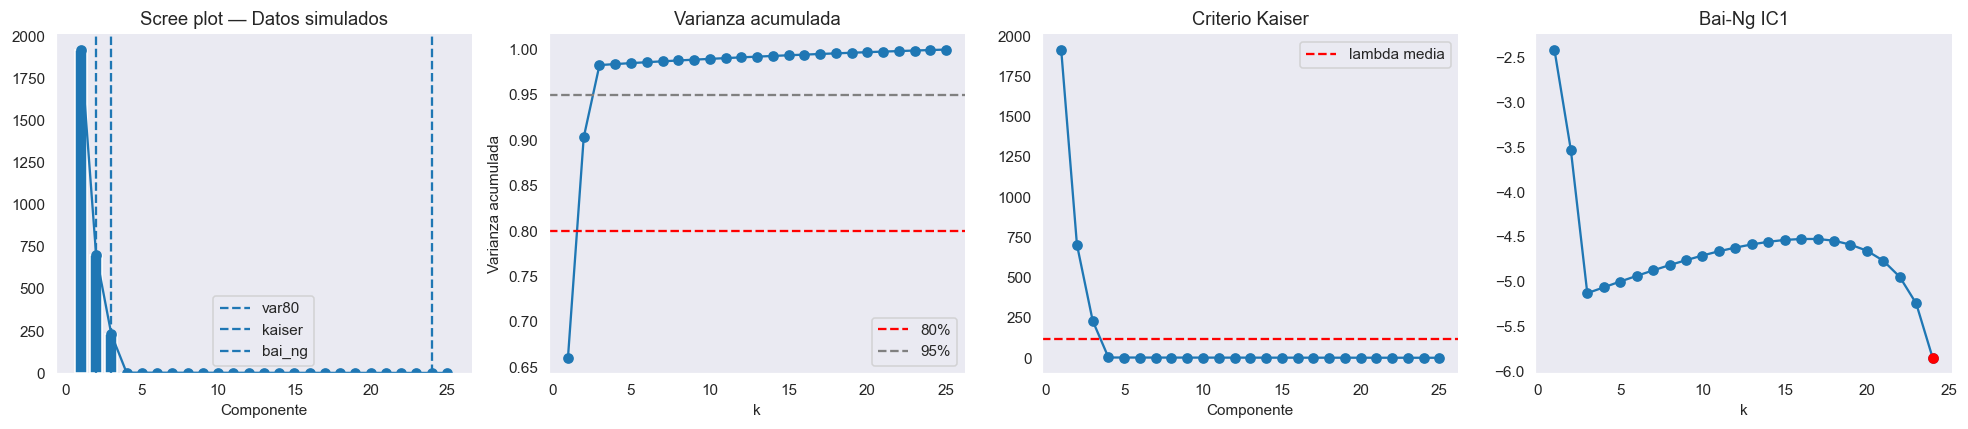

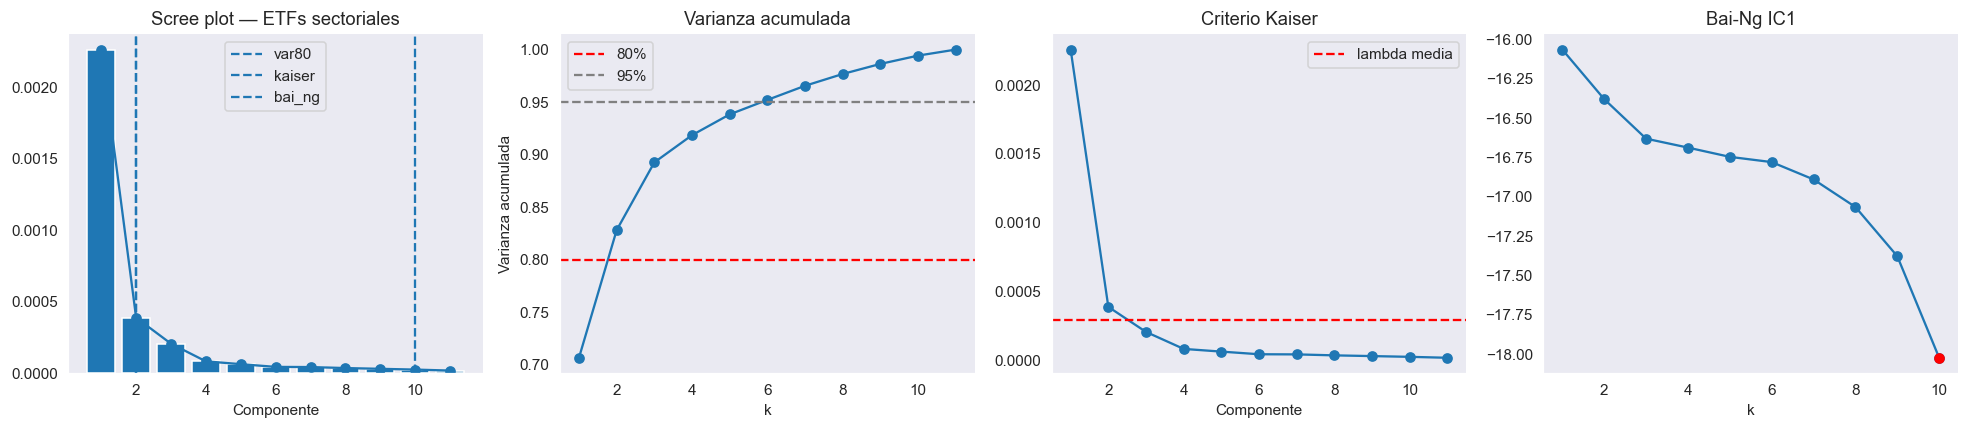

In [17]:
# Descarga ETFs sectoriales
sector_tickers = ['XLK','XLF','XLV','XLY','XLC','XLI','XLE','XLU','XLRE','XLP','XLB']
raw_sec = yf.download(sector_tickers, start='2020-01-01', end='2024-01-01',
                      progress=False, auto_adjust=True)['Close']
ret_sec = raw_sec.pct_change().dropna()[sector_tickers]
print(f'ETFs: {ret_sec.shape[0]} dias | {ret_sec.shape[1]} sectores')
print(f'Periodo: {ret_sec.index[0].date()} — {ret_sec.index[-1].date()}')

pca_full_sec = PCA().fit(ret_sec.values)
eigenvals_sec = pca_full_sec.explained_variance_
k_dict_sec = select_k_criteria(eigenvals_sec, ret_sec.shape[1], ret_sec.shape[0])
print(f'ETFs sectoriales: {k_dict_sec}')

def plot_k_criteria(eigenvalues, k_dict, title):
    ev_ratio = eigenvalues / eigenvalues.sum()
    cum_var = np.cumsum(ev_ratio)
    lambda_mean = eigenvalues.mean()

    n = len(eigenvalues)
    T = T_sim if title == 'Datos simulados' else ret_sec.shape[0]

    g_nT = (n + T) / (n * T) * np.log(n * T / (n + T))
    ks = np.arange(1, n)
    ic = []

    for k in ks:
        V_k = eigenvalues[k:].sum() / (n * T)
        ic.append(np.log(V_k + 1e-12) + k * g_nT)

    fig, ax = plt.subplots(1, 4, figsize=(18, 4))

    ax[0].bar(np.arange(1, n + 1), eigenvalues)
    ax[0].plot(np.arange(1, n + 1), eigenvalues, marker='o')
    for label, k_val in k_dict.items():
        ax[0].axvline(k_val, linestyle='--', label=label)
    ax[0].set_title(f'Scree plot — {title}')
    ax[0].set_xlabel('Componente')
    ax[0].legend()

    ax[1].plot(np.arange(1, n + 1), cum_var, marker='o')
    ax[1].axhline(0.80, linestyle='--', color='red', label='80%')
    ax[1].axhline(0.95, linestyle='--', color='gray', label='95%')
    ax[1].set_title('Varianza acumulada')
    ax[1].set_xlabel('k')
    ax[1].set_ylabel('Varianza acumulada')
    ax[1].legend()

    ax[2].plot(np.arange(1, n + 1), eigenvalues, marker='o')
    ax[2].axhline(lambda_mean, linestyle='--', color='red', label='lambda media')
    ax[2].set_title('Criterio Kaiser')
    ax[2].set_xlabel('Componente')
    ax[2].legend()

    ax[3].plot(ks, ic, marker='o')
    ax[3].scatter(k_dict['bai_ng'], ic[k_dict['bai_ng'] - 1], color='red', zorder=3)
    ax[3].set_title('Bai-Ng IC1')
    ax[3].set_xlabel('k')

    plt.tight_layout()
    plt.show()


plot_k_criteria(eigenvals_sim, k_dict_sim, 'Datos simulados')
plot_k_criteria(eigenvals_sec, k_dict_sec, 'ETFs sectoriales')

**Responde (mínimo 2 oraciones por pregunta):**

**a)** En los datos simulados con $k_{\text{verdadero}}=3$, ¿cuál de los tres criterios recupera el valor correcto? ¿Por qué los otros pueden sobre/sub-estimar $k$?

> En los datos simulados, el criterio de Kaiser recupera correctamente el valor verdadero, seleccionando k = 3. Esto ocurre porque los tres primeros factores tienen eigenvalores claramente superiores al promedio, mientras que los restantes representan principalmente ruido. El criterio de varianza acumulada subestima el número de factores al seleccionar k = 2, porque los dos primeros componentes concentran más del 80% de la varianza. En cambio, Bai-Ng sobreestima k, ya que sigue reduciendo la varianza residual al incorporar componentes adicionales de baja magnitud.

**b)** Para los ETFs sectoriales reales, ¿los tres criterios coinciden? ¿Qué interpretación económica tiene el $k$ seleccionado por Bai-Ng?

> En los ETFs sectoriales reales, los tres criterios no coinciden: varianza acumulada y Kaiser seleccionan k = 2, mientras que Bai-Ng selecciona k = 10. Esto muestra que, en datos reales, la elección de k depende fuertemente del criterio utilizado. Económicamente, el k seleccionado por Bai-Ng sugiere una estructura más granular de factores sectoriales, donde además del factor de mercado común existen componentes específicos asociados a sectores como tecnología, energía, salud o consumo.

**c)** El criterio de Kaiser fue diseñado para datos estandarizados (con varianza unitaria por variable). ¿Qué error cometes si aplicas Kaiser sobre retornos sin estandarizar?

> El criterio de Kaiser debe aplicarse sobre datos estandarizados, porque compara cada eigenvalor con la varianza promedio de una variable, que debería ser igual a 1. Si se aplica sobre retornos sin estandarizar, los activos con mayor volatilidad dominan los eigenvalores. El error sería interpretar como “factores importantes” componentes que en realidad reflejan diferencias de escala o volatilidad entre activos, y no necesariamente fuentes comunes de riesgo.

---
## Parte 2 — PCA en la Curva de Tasas de Interés *(25 pts)*

### Contexto

Litterman & Scheinkman (1991) demostraron que los tres primeros componentes de la curva soberana tienen interpretación directa: **nivel**, **pendiente** y **curvatura**. Estos factores son la base del análisis de riesgo de tasa en portafolios de renta fija.

Trabajarás con datos simulados usando el modelo Nelson-Siegel:

$$y(\tau) = f_1 \cdot L_1(\tau) + f_2 \cdot L_2(\tau) + f_3 \cdot L_3(\tau) + \varepsilon(\tau)$$

donde los loadings son:
$$L_1(\tau) = 1, \quad L_2(\tau) = \frac{1 - e^{-\lambda\tau}}{\lambda\tau}, \quad L_3(\tau) = \frac{1 - e^{-\lambda\tau}}{\lambda\tau} - e^{-\lambda\tau}$$

y los factores siguen procesos AR(1) con alta persistencia.

### 2.1 — Simulación y PCA en la Curva *(10 pts)*

La celda de datos ya genera la curva simulada. Tu tarea es:

1. Aplicar PCA sobre los **cambios diarios de tasas** $\Delta y_t$ (primeras diferencias) — **no sobre niveles**
2. Identificar cuántos componentes explican el 99% de la varianza
3. Visualizar los loadings de los 3 primeros PCs vs tenor y comparar con las curvas Nelson-Siegel teóricas
4. Verificar que PCA recupera la estructura Nelson-Siegel calculando la correlación entre el loading del PC1 y $L_1$, PC2 y $L_2$, PC3 y $L_3$

**Regla de signo:** ajusta el signo de cada PC para que el loading promedio sea positivo (PC1 y PC3) o para que el loading en $\tau=0.25$ sea mayor que el loading en $\tau=30$ (PC2).

Curva de tasas: 2000 periodos | 11 tenores
Cambios diarios: shape=(1999, 11)
Tenores: [ 0.25  0.5   1.    2.    3.    5.    7.   10.   15.   20.   30.  ]
Componentes para explicar 99%: 2


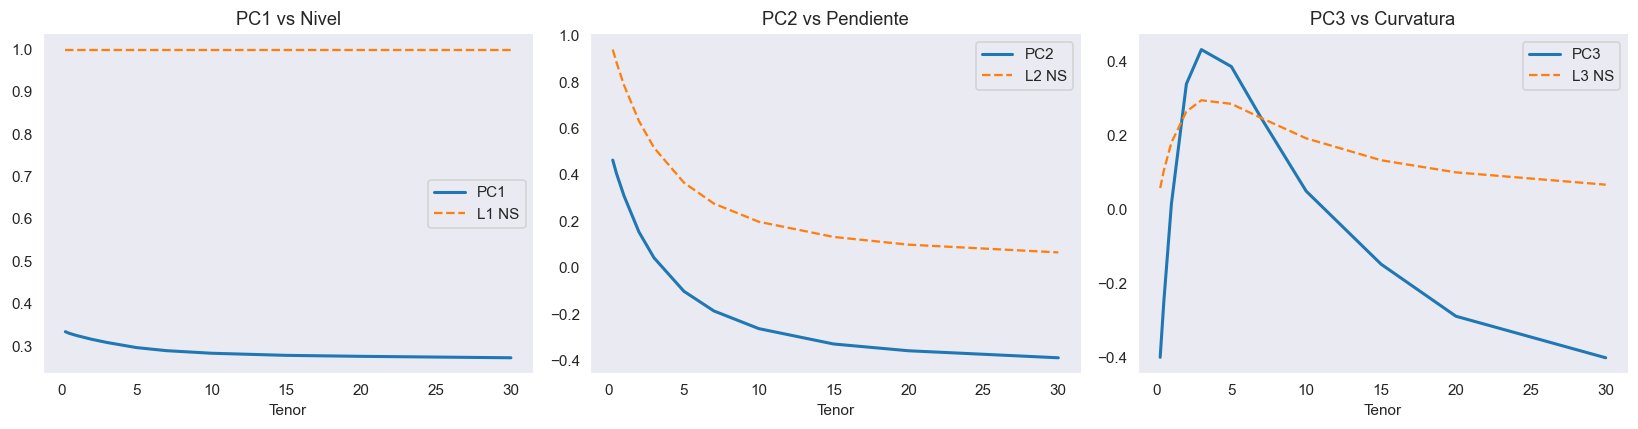

Correlacion PC1-L1: no definida (L1 es constante)
Correlacion PC2-L2: 1.000
Correlacion PC3-L3: 0.999


In [19]:
# Generación de datos de curva de tasas
np.random.seed(2026)
tenors = np.array([0.25, 0.5, 1, 2, 3, 5, 7, 10, 15, 20, 30])
T_yc   = 2000
lam_ns = 0.5

# Loadings Nelson-Siegel teoricos
L1_ns = np.ones(len(tenors))
L2_ns = (1 - np.exp(-lam_ns * tenors)) / (lam_ns * tenors)
L3_ns = L2_ns - np.exp(-lam_ns * tenors)

# Factores AR(1)
def ar1(T, phi, sigma, mu=0, seed=None):
    rng = np.random.default_rng(seed)
    x = np.zeros(T)
    x[0] = mu
    eps = rng.normal(0, sigma, T)
    for t in range(1, T):
        x[t] = mu + phi * (x[t-1] - mu) + eps[t]
    return x

f1_yc = ar1(T_yc, 0.998, 0.02, mu=0.04, seed=1)
f2_yc = ar1(T_yc, 0.995, 0.015, mu=0.01, seed=2)
f3_yc = ar1(T_yc, 0.990, 0.010, mu=0.00, seed=3)

yields_yc = (np.outer(f1_yc, L1_ns) +
             np.outer(f2_yc, L2_ns) +
             np.outer(f3_yc, L3_ns) +
             np.random.randn(T_yc, len(tenors)) * 0.001)

dy_yc = np.diff(yields_yc, axis=0)
print(f'Curva de tasas: {T_yc} periodos | {len(tenors)} tenores')
print(f'Cambios diarios: shape={dy_yc.shape}')
print(f'Tenores: {tenors}')

pca_yc = PCA().fit(dy_yc)

ev_yc = pca_yc.explained_variance_ratio_
k_99 = np.searchsorted(np.cumsum(ev_yc), 0.99) + 1

print(f'Componentes para explicar 99%: {k_99}')

components_yc = pca_yc.components_[:3].copy()

# Regla de signo
if components_yc[0].mean() < 0:
    components_yc[0] *= -1

if components_yc[1][0] < components_yc[1][-1]:
    components_yc[1] *= -1

if np.corrcoef(components_yc[2], L3_ns)[0, 1] < 0:
    components_yc[2] *= -1

ns_loadings = [L1_ns, L2_ns, L3_ns]
titles = ['PC1 vs Nivel', 'PC2 vs Pendiente', 'PC3 vs Curvatura']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, ax in enumerate(axes):
    ax.plot(tenors, components_yc[i], label=f'PC{i+1}', lw=2)
    ax.plot(tenors, ns_loadings[i], '--', label=f'L{i+1} NS')
    ax.set_title(titles[i])
    ax.set_xlabel('Tenor')
    ax.legend()

plt.tight_layout()
plt.show()

corr_1 = np.corrcoef(components_yc[0], L1_ns)[0, 1]
corr_2 = np.corrcoef(components_yc[1], L2_ns)[0, 1]
corr_3 = np.corrcoef(components_yc[2], L3_ns)[0, 1]

print('Correlacion PC1-L1: no definida (L1 es constante)')
print(f'Correlacion PC2-L2: {corr_2:.3f}')
print(f'Correlacion PC3-L3: {corr_3:.3f}')

El PCA sobre cambios diarios de tasas recupera claramente la estructura de pendiente y curvatura del modelo Nelson-Siegel. La correlación entre PC2 y L2 fue 1.000, mientras que la correlación entre PC3 y L3 fue 0.999. Para PC1, la correlación con L1 no está definida porque L1 es constante, pero visualmente el primer componente representa un movimiento común de nivel en la curva.

### 2.2 — DV01 Factorial y Construcción de Portafolio Inmune al Nivel *(15 pts)*

#### DV01 por factor

El **DV01** (*Dollar Value of 01*) de un bono es la sensibilidad del precio ante un movimiento de 1 punto base (0.01%) en la tasa. Para un portafolio con posición $w_i$ en el bono del tenor $\tau_i$:

$$\text{DV01}_{\text{portafolio}} \approx \sum_i w_i \cdot \underbrace{(-D_i \cdot P_i \cdot 0.0001)}_{\text{DV01 individual}}$$

donde $D_i$ es la duración modificada del bono $i$. Aproximando la duración por el tenor: $D_i \approx \tau_i$.

El **DV01 factorial** descompone la exposición del portafolio a cada factor PCA:

$$\text{DV01}_{\text{PC}j} = \sum_i w_i \cdot (-\tau_i) \cdot b_{ij} \cdot 0.0001$$

donde $b_{ij}$ es el loading del bono $i$ en el factor $j$ (componente $j$ del PCA evaluado en el tenor $\tau_i$).

#### Portafolio neutral al nivel, largo en curvatura

Un *butterfly trade* consiste en:
- Ser **largo** en el bono de vencimiento medio (5 años)
- Ser **corto** en los extremos (2 y 10 años)
- **Neutro** al riesgo de nivel: $\text{DV01}_{\text{PC1}} = 0$
- **Máxima exposición** al factor de curvatura: $|\text{DV01}_{\text{PC3}}|$ maximizado

**Requisitos:**
1. Implementar `dv01_factorial(weights, tenors, loadings)` que retorna el DV01 de cada factor
2. Construir un butterfly 3-bono (tenores: 2, 5, 10 años) con pesos $w = [w_1, 1, w_3]$, encontrando $w_1, w_3$ tal que $\text{DV01}_{\text{PC1}} = 0$ y $\sum w_i = 0$ (portafolio auto-financiado)
3. Reportar el DV01 de los 3 primeros factores para este portafolio
4. Visualizar la distribución de P&L simulada del portafolio vs un portafolio largo en 5Y solamente

Pesos butterfly: 2Y=-0.613, 5Y=1.000, 10Y=-0.387
  DV01 PC1: 0.000000
  DV01 PC2: -0.000032
  DV01 PC3: -0.000132


,Butterfly,Long 5Y
Media,0.000067,-0.000760
Volatilidad,0.011025,0.106259
Sharpe,0.006041,-0.007157


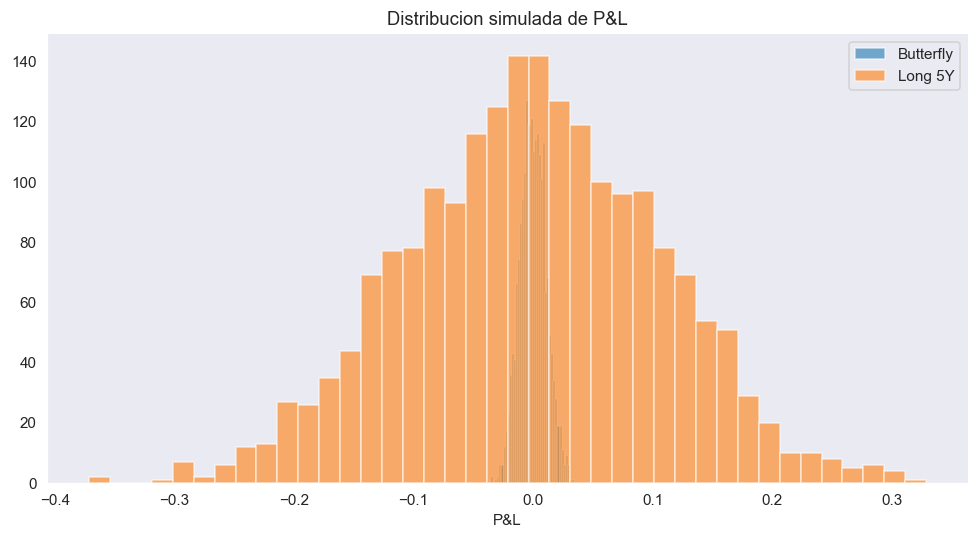

In [20]:
def dv01_factorial(weights, tenors_pos, loadings_k):
    """
    Calcula el DV01 factorial de un portafolio de bonos.

    Parameters
    ----------
    weights      : array (m,)   — pesos del portafolio en cada bono
    tenors_pos   : array (m,)   — tenores de los bonos en el portafolio
    loadings_k   : array (k, m) — loadings PCA evaluados en cada tenor
                   loadings_k[j, i] = loading del factor j en el tenor i

    Returns
    -------
    dv01 : array (k,) — DV01 de cada factor (en terminos de precio por $1M nocional)

    Formula:
    dv01[j] = sum_i(weights[i] * (-tenors_pos[i]) * loadings_k[j, i] * 0.0001)
    """
    weights = np.asarray(weights)
    tenors_pos = np.asarray(tenors_pos)

    dv01 = np.sum(weights * (-tenors_pos) * loadings_k * 0.0001, axis=1)

    return dv01


# Descomenta cuando hayas completado la Parte 2.1

# Tenores del butterfly
butterfly_tenors = np.array([2.0, 5.0, 10.0])

idx_2y  = np.argmin(np.abs(tenors - 2.0))
idx_5y  = np.argmin(np.abs(tenors - 5.0))
idx_10y = np.argmin(np.abs(tenors - 10.0))

comps_yc = pca_yc.components_[:3].copy()

# Ajusta signos igual que en 2.1
if comps_yc[0].mean() < 0:
    comps_yc[0] *= -1

if comps_yc[1][0] < comps_yc[1][-1]:
    comps_yc[1] *= -1

if np.corrcoef(comps_yc[2], L3_ns)[0, 1] < 0:
    comps_yc[2] *= -1

loadings_butterfly = comps_yc[:, [idx_2y, idx_5y, idx_10y]]

# Sistema:
# w1 + w3 = -1
# w1*a1 + 1*a5 + w3*a10 = 0, donde ai = -tenor_i * loading_PC1_i
a = -butterfly_tenors * loadings_butterfly[0]

A = np.array([
    [1.0, 1.0],
    [a[0], a[2]]
])

b = np.array([
    -1.0,
    -a[1]
])

w1, w3 = np.linalg.solve(A, b)

w_bf = np.array([w1, 1.0, w3])

dv01_bf = dv01_factorial(w_bf, butterfly_tenors, loadings_butterfly)

print(f'Pesos butterfly: 2Y={w1:.3f}, 5Y=1.000, 10Y={w3:.3f}')

for j, d in enumerate(dv01_bf):
    print(f'  DV01 PC{j+1}: {d:.6f}')

idx_bf = [idx_2y, idx_5y, idx_10y]

pnl_bf = np.sum(
    w_bf * (-butterfly_tenors) * dy_yc[:, idx_bf],
    axis=1
)

pnl_long5y = -5.0 * dy_yc[:, idx_5y]

stats_pnl = pd.DataFrame({
    'Butterfly': [
        pnl_bf.mean(),
        pnl_bf.std(),
        pnl_bf.mean() / (pnl_bf.std() + 1e-9)
    ],
    'Long 5Y': [
        pnl_long5y.mean(),
        pnl_long5y.std(),
        pnl_long5y.mean() / (pnl_long5y.std() + 1e-9)
    ]
}, index=['Media', 'Volatilidad', 'Sharpe'])

display(stats_pnl.round(6))

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(pnl_bf, bins=40, alpha=0.6, label='Butterfly')
ax.hist(pnl_long5y, bins=40, alpha=0.6, label='Long 5Y')

ax.set_title('Distribucion simulada de P&L')
ax.set_xlabel('P&L')
ax.legend()

plt.tight_layout()
plt.show()

**Responde (mínimo 2 oraciones por pregunta):**

**a)** ¿Los loadings del PCA recuperados en 2.1 se parecen a los loadings Nelson-Siegel teóricos? ¿Qué correlaciones obtienes? ¿Cuántos puntos base de varianza explica cada factor?

> Los loadings del PCA recuperados en 2.1 se parecen principalmente a los loadings de pendiente y curvatura del modelo Nelson-Siegel. La correlación PC2-L2 fue 1.000 y la correlación PC3-L3 fue 0.999; para PC1-L1 la correlación no está definida porque L1 es constante. Además, el PCA mostró que solo 2 componentes explican el 99% de la varianza de los cambios diarios de tasas. Esto indica que la mayor parte del riesgo de la curva está concentrada en pocos factores.

**b)** ¿Cuáles son los pesos $w_1$ y $w_3$ del butterfly encontrado? Interpreta el signo de cada peso: ¿por qué el bono de 2Y y el de 10Y deben tener signos distintos al de 5Y en este trade?

> Los pesos encontrados fueron w1 = -0.613 para el bono de 2Y, 1.000 para el bono de 5Y y w3 = -0.387 para el bono de 10Y. El peso positivo en 5Y y los pesos negativos en 2Y y 10Y corresponden a un butterfly trade clásico. Los bonos de 2Y y 10Y tienen signo contrario al de 5Y porque el portafolio busca estar largo en curvatura y, al mismo tiempo, neutralizar la exposición al factor de nivel. Por eso se toma una posición larga en el vencimiento medio y posiciones cortas en los extremos.

**c)** Compara la distribución del P&L del butterfly vs la posición larga en 5Y. ¿Cuál tiene mayor volatilidad? ¿Cuál tiene mayor sharpe ratio empírico (usando la distribución simulada)? ¿Tiene sentido desde la teoría?

> La posición long 5Y tiene una volatilidad mucho mayor que el butterfly, con 0.1063 frente a 0.0110. Esto muestra que el butterfly reduce de forma importante la exposición direccional a movimientos paralelos de la curva. El butterfly tuvo un Sharpe empírico ligeramente positivo, mientras que la posición long 5Y tuvo un Sharpe negativo. Esto tiene sentido desde la teoría, porque el butterfly fue construido para neutralizar el riesgo de nivel y concentrar la exposición en curvatura, reduciendo la volatilidad total del portafolio.

---
## Parte 3 — PCA en Renta Variable: Shrinkage y Portafolios *(25 pts)*

### Contexto

Un portafolio de $n$ acciones necesita una estimación de $\Sigma \in \mathbb{R}^{n \times n}$ para la optimización de mínima varianza. La estimación muestral $\hat{\Sigma}$ falla cuando $T$ es moderado respecto a $n$ porque:

1. Los eigenvalores pequeños son **subestimados** y los grandes **sobreestimados** (Marchenko-Pastur)
2. La inversa $\hat{\Sigma}^{-1}$ amplifica el ruido — los pesos de Markowitz se vuelven extremos

La solución: **covarianza shrinkage via PCA**:

$$\hat{\Sigma}_{\text{PCA}} = \underbrace{\hat{B}_k \hat{B}_k^\top}_{\text{sistemático}} + \underbrace{\hat{D}}_{\text{idiosincrático}}, \quad \hat{D} = \text{diag}(\hat{\Sigma} - \hat{B}_k \hat{B}_k^\top)$$

Esta matriz tiene exactamente $k$ eigenvalores grandes (los factores) y $n-k$ eigenvalores iguales al ruido idiosincrático — mucho mejor condicionada que $\hat{\Sigma}$.

### 3.1 — Loadings Factoriales y Estructura de Sectores *(8 pts)*

Usa los datos de los 11 ETFs sectoriales descargados en la Parte 1.

**Requisitos:**
1. Ajustar PCA con $k=4$ componentes sobre `ret_sec`
2. Generar un **heatmap de loadings** (sectores × PCs) con anotaciones, coloreado en divergente (`RdBu_r`)
3. Para PC1, graficar los loadings como barras horizontales coloreadas por signo y ordenadas de mayor a menor
4. Calcular el **factor de correlación de mercado** de PC1: $\rho_{\text{MKT}} = \text{corr}(\text{score}_{\text{PC1}}, r_{\text{SPY}})$, descargando SPY del mismo período
5. Responder las preguntas de interpretación

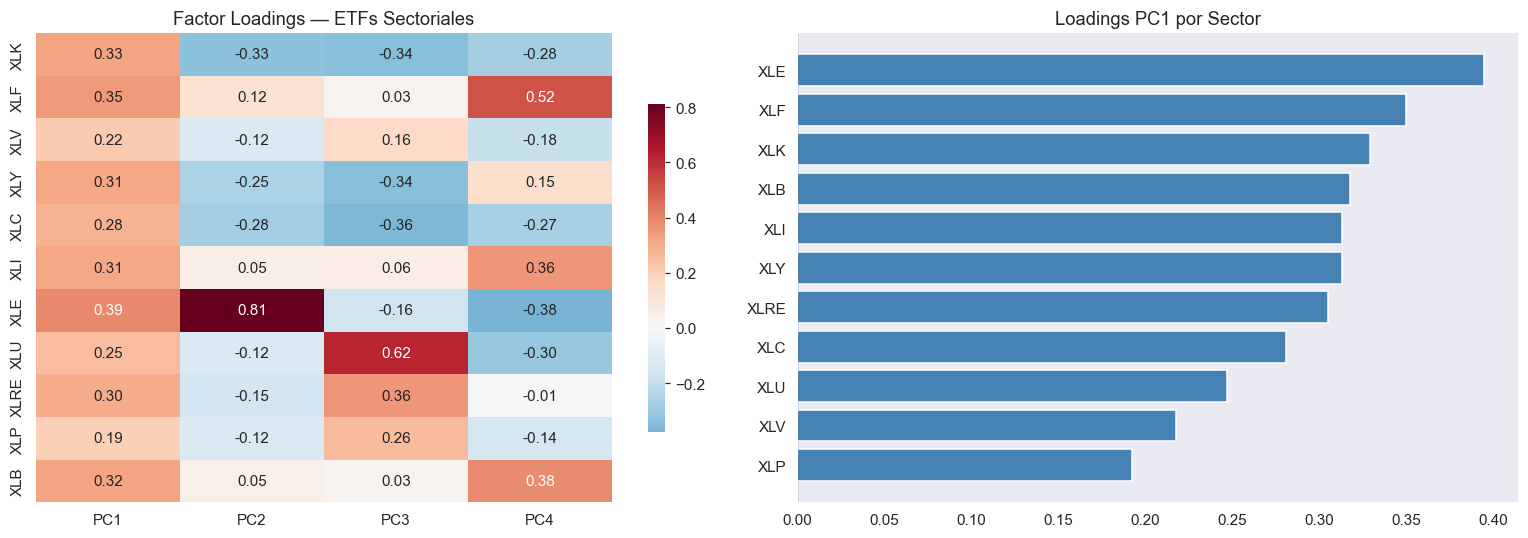

Correlacion PC1 con SPY: 0.970


In [25]:
pca_sec = PCA(n_components=4).fit(ret_sec.values)
scores_sec = pca_sec.transform(ret_sec.values)

# Heatmap de loadings
loadings_df = pd.DataFrame(
    pca_sec.components_.T,
    index=sector_tickers,
    columns=[f'PC{i+1}' for i in range(4)]
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(
    loadings_df,
    ax=axes[0],
    cmap='RdBu_r',
    center=0,
    annot=True,
    fmt='.2f',
    cbar_kws={'shrink': 0.7}
)

axes[0].set_title('Factor Loadings — ETFs Sectoriales')

# Barplot PC1
pc1_loadings = loadings_df['PC1'].sort_values()

colors_bar = ['tomato' if v < 0 else 'steelblue' for v in pc1_loadings]

axes[1].barh(
    pc1_loadings.index,
    pc1_loadings.values,
    color=colors_bar
)

axes[1].set_title('Loadings PC1 por Sector')
axes[1].axvline(0, color='black', lw=0.8)

plt.tight_layout()
plt.show()

# Correlación PC1 con SPY
spy_data = yf.download(
    'SPY',
    start='2020-01-01',
    end='2024-01-01',
    progress=False,
    auto_adjust=True
)['Close']

ret_spy = spy_data.pct_change().dropna().reindex(ret_sec.index).dropna()

# Garantiza que sea un vector 1D
ret_spy = np.asarray(ret_spy).reshape(-1)

scores_pc1 = scores_sec[:, 0]

corr_pc1_spy = np.corrcoef(scores_pc1, ret_spy)[0, 1]

print(f'Correlacion PC1 con SPY: {corr_pc1_spy:.3f}')

**Responde (mínimo 2 oraciones por pregunta):**

**a)** ¿Cuál es la correlación de PC1 con el retorno del SPY? ¿Qué dice esto sobre la interpretación del primer componente como un "factor de mercado"?

> La correlación entre el primer componente principal (PC1) y los retornos del SPY fue de 0.970, lo que indica una relación muy fuerte entre ambos. Esto confirma que PC1 puede interpretarse como un factor de mercado, ya que captura el movimiento común que afecta simultáneamente a la mayoría de los sectores. Además, todos los sectores presentan loadings positivos en PC1, lo que refuerza la interpretación de que este componente representa el riesgo sistemático del mercado y no un comportamiento específico de un sector.

**b)** Identifica qué sectores tienen loadings más negativos en PC2. ¿Qué hipótesis económica plantearías sobre qué separa a esos sectores del grupo con loading positivo?

> Los loadings más negativos en PC2 corresponden principalmente a los sectores de Energía (XLE), Tecnología (XLK), Servicios de Comunicación (XLC) y Consumo Discrecional (XLY), mientras que el mayor loading positivo corresponde al sector Financiero (XLF). Esto sugiere que PC2 diferencia sectores cíclicos de aquellos que reaccionan de manera distinta a cambios en el entorno macroeconómico. Una posible interpretación económica es que este componente refleja diferencias en la sensibilidad a variables como tasas de interés, crecimiento económico o precios de las materias primas. En este caso, el sector energético presenta un comportamiento claramente diferenciado respecto del resto de los sectores.

### 3.2 — Covarianza Shrinkage: Implementación y Condicionamiento *(10 pts)*

Implementa la función `pca_shrinkage_cov(X, k)` que construye $\hat{\Sigma}_{\text{PCA}}$.

**Pasos:**
1. Ajustar PCA con $k$ componentes
2. Calcular $\hat{B}_k \in \mathbb{R}^{n \times k}$: $\hat{B}_k = V_k \cdot \text{diag}(\sqrt{\lambda_1}, \dots, \sqrt{\lambda_k})$ donde $V_k$ son los eigenvectores
3. Calcular la covarianza muestral $\hat{\Sigma}$
4. Calcular $\hat{D} = \text{diag}(\hat{\Sigma} - \hat{B}_k \hat{B}_k^\top)$, clipeando a `max(1e-8, .)`
5. Retornar $\hat{\Sigma}_{\text{PCA}} = \hat{B}_k \hat{B}_k^\top + \hat{D}$

**Verificación:** $\hat{\Sigma}_{\text{PCA}}$ debe tener exactamente $k$ eigenvalores significativamente mayores que los demás.

**Análisis:** compara el número de condición $\kappa(\hat{\Sigma})$ vs $\kappa(\hat{\Sigma}_{\text{PCA}})$ para $k \in \{1, 2, 3, 4, 5\}$.

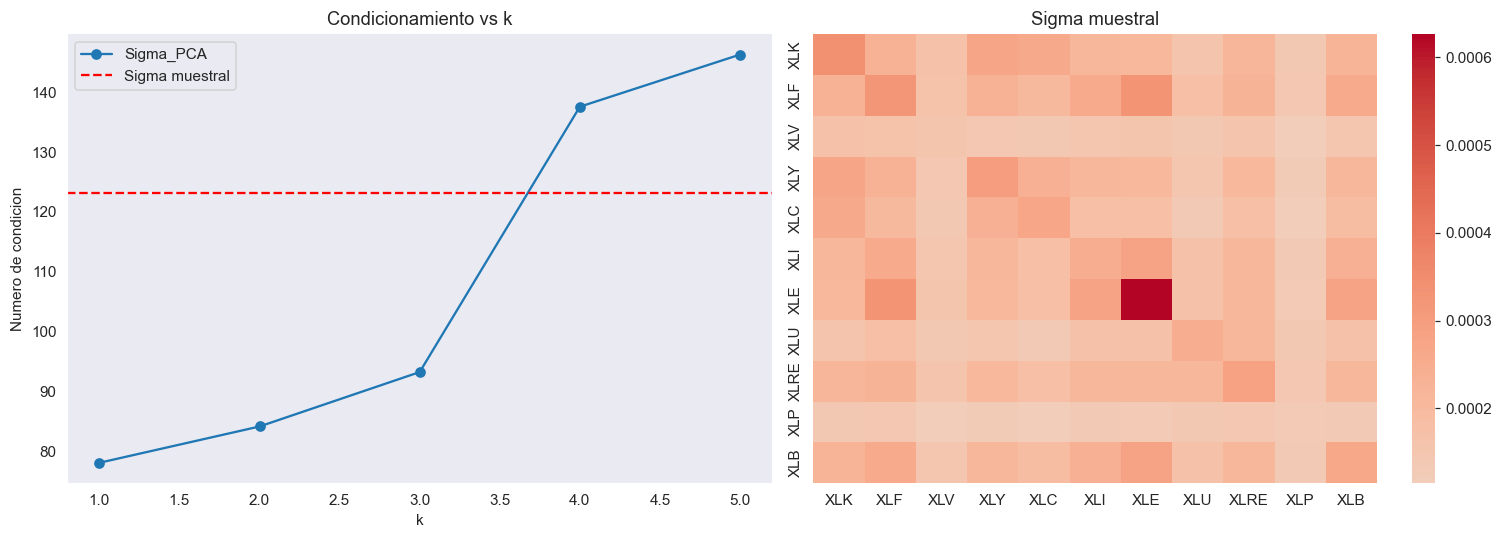

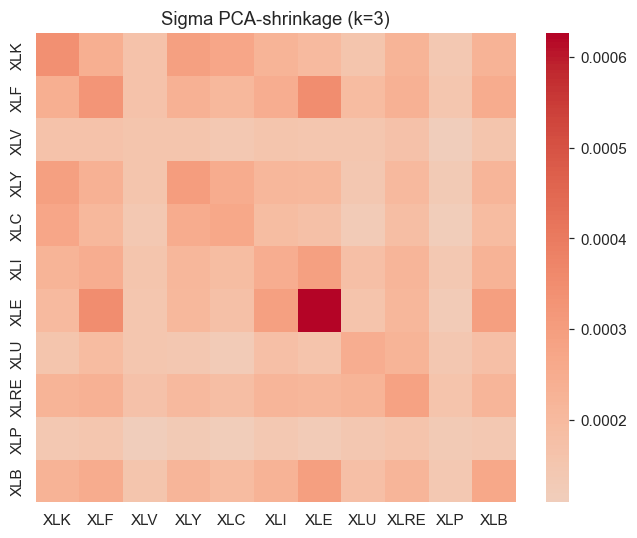

Eigenvalores Sigma_PCA(k=3): [2.289e-03 4.070e-04 2.360e-04 4.100e-05 3.900e-05 3.600e-05 3.300e-05
 3.300e-05 2.900e-05 2.900e-05 2.500e-05]


In [26]:
def pca_shrinkage_cov(X, k):
    """
    Covarianza shrinkage via PCA: Sigma_PCA = B_k @ B_k.T + D

    Parameters
    ----------
    X : array (T, n) — retornos crudos
    k : int          — numero de factores

    Returns
    -------
    Sigma_pca : array (n, n) — covarianza PCA-shrinkage
    B_hat     : array (n, k) — factor loadings
    D_hat     : array (n, n) — covarianza idiosincratica (diagonal)
    """
    pca_k = PCA(n_components=k).fit(X)

    B_hat = pca_k.components_.T * np.sqrt(pca_k.explained_variance_)

    Sigma_sample = np.cov(X.T)

    D_diag = np.diag(Sigma_sample - B_hat @ B_hat.T)
    D_diag = np.maximum(D_diag, 1e-8)

    D_hat = np.diag(D_diag)

    Sigma_pca = B_hat @ B_hat.T + D_hat

    return Sigma_pca, B_hat, D_hat


Sigma_sample = np.cov(ret_sec.values.T)
cond_sample  = np.linalg.cond(Sigma_sample)

k_values  = [1, 2, 3, 4, 5]
cond_pca_list = []
for k_try in k_values:
    Sigma_pca_try, _, _ = pca_shrinkage_cov(ret_sec.values, k_try)
    cond_pca_list.append(np.linalg.cond(Sigma_pca_try))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(k_values, cond_pca_list, 'o-', label='Sigma_PCA')
ax1.axhline(cond_sample, color='red', ls='--', label='Sigma muestral')
ax1.set_xlabel('k')
ax1.set_ylabel('Numero de condicion')
ax1.set_title('Condicionamiento vs k')
ax1.legend()

Sigma_pca3, _, _ = pca_shrinkage_cov(ret_sec.values, 3)

sns.heatmap(
    Sigma_sample,
    ax=ax2,
    xticklabels=sector_tickers,
    yticklabels=sector_tickers,
    cmap='coolwarm',
    center=0
)
ax2.set_title('Sigma muestral')

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))

sns.heatmap(
    Sigma_pca3,
    ax=ax,
    xticklabels=sector_tickers,
    yticklabels=sector_tickers,
    cmap='coolwarm',
    center=0
)
ax.set_title('Sigma PCA-shrinkage (k=3)')

plt.tight_layout()
plt.show()

evals_pca3 = np.linalg.eigvalsh(Sigma_pca3)[::-1]
print(f'Eigenvalores Sigma_PCA(k=3): {evals_pca3.round(6)}')

### 3.3 — Portafolio de Mínima Varianza: Sigma Muestral vs Sigma PCA *(7 pts)*

El portafolio de **mínima varianza global** (GMV) se obtiene de:

$$w^* = \arg\min_w \; w^\top \Sigma w \quad \text{s.t.} \quad \mathbf{1}^\top w = 1$$

La solución analítica es:

$$w^* = \frac{\Sigma^{-1} \mathbf{1}}{\mathbf{1}^\top \Sigma^{-1} \mathbf{1}}$$

**Requisitos:**
1. Implementar `gmv_portfolio(Sigma)` usando la fórmula analítica con `np.linalg.solve`
2. Dividir los datos en train (80%) y test (20%) — **sin shuffle** (respeta el orden temporal)
3. Calcular $w^*_{\text{muestral}}$ y $w^*_{\text{PCA}}$ con $k=3$ sobre el conjunto train
4. Comparar **en el conjunto test**: retorno anualizado, volatilidad anualizada y Sharpe ratio
5. Graficar: (a) pesos de cada portafolio lado a lado, (b) retorno acumulado en test

Train: 804 dias | Test: 201 dias
Pesos GMV muestral: min=-0.532, max=0.811
Pesos GMV PCA:      min=-0.346,    max=0.927


,Retorno anual,Vol anual,Sharpe
GMV muestral,0.0131,0.1304,0.1003
GMV PCA,0.0090,0.1344,0.0673


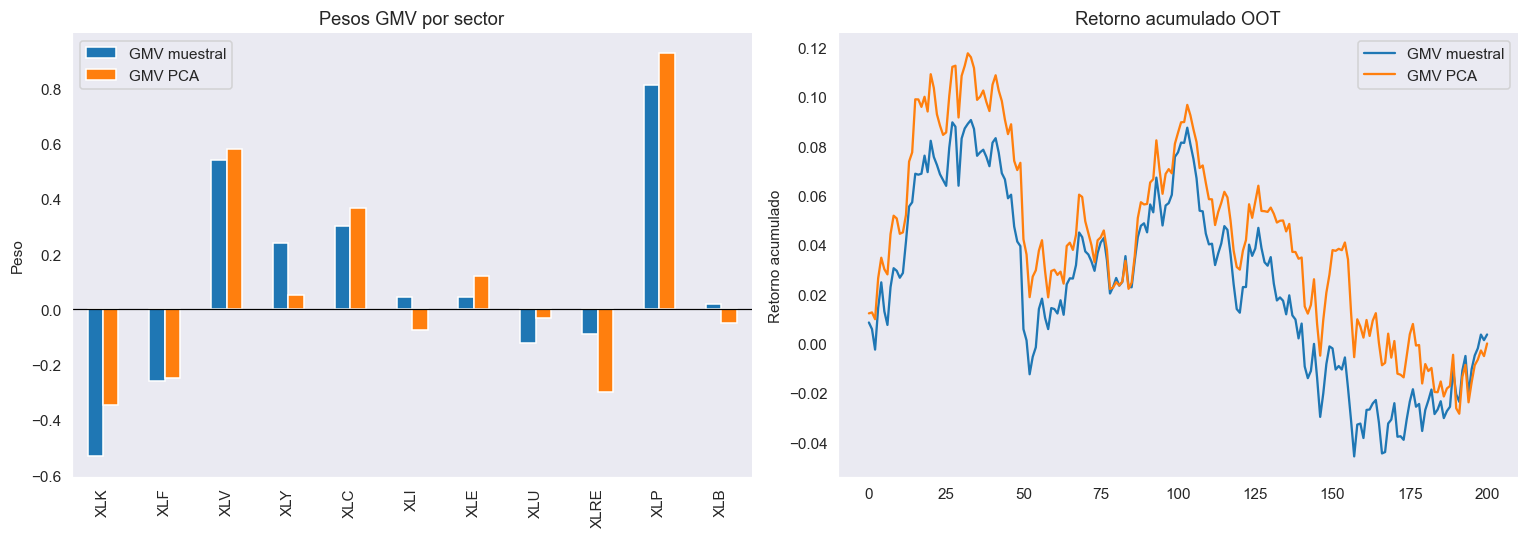

In [29]:
def gmv_portfolio(Sigma):
    """
    Portafolio de minima varianza global (GMV).

    w* = Sigma^{-1} @ 1 / (1.T @ Sigma^{-1} @ 1)

    Usa np.linalg.solve en lugar de invertir directamente.
    Pista: np.linalg.solve(Sigma, ones) equivale a Sigma^{-1} @ ones

    Parameters
    ----------
    Sigma : array (n, n) — matriz de covarianza

    Returns
    -------
    w : array (n,) — pesos del portafolio (suman 1)
    """
    ones = np.ones(Sigma.shape[0])

    x = np.linalg.solve(Sigma, ones)

    w = x / (ones @ x)

    return w


#Split temporal 80/20
n_test  = int(len(ret_sec) * 0.20)
ret_tr  = ret_sec.iloc[:-n_test].values
ret_te  = ret_sec.iloc[-n_test:].values
print(f'Train: {len(ret_tr)} dias | Test: {len(ret_te)} dias')

# Covarianzas estimadas en train
Sigma_sample_tr = np.cov(ret_tr.T)
Sigma_pca_tr, _, _ = pca_shrinkage_cov(ret_tr, k=3)

# Portafolios GMV
w_sample = gmv_portfolio(Sigma_sample_tr)
w_pca    = gmv_portfolio(Sigma_pca_tr)

print(f'Pesos GMV muestral: min={w_sample.min():.3f}, max={w_sample.max():.3f}')
print(f'Pesos GMV PCA:      min={w_pca.min():.3f},    max={w_pca.max():.3f}')

r_sample_oot = ret_te @ w_sample
r_pca_oot    = ret_te @ w_pca

def portfolio_metrics(r, freq=252):
    return {
        'Retorno anual': r.mean() * freq,
        'Vol anual': r.std() * np.sqrt(freq),
        'Sharpe': r.mean() / r.std() * np.sqrt(freq)
    }

metrics_gmv = pd.DataFrame({
    'GMV muestral': portfolio_metrics(r_sample_oot),
    'GMV PCA': portfolio_metrics(r_pca_oot)
}).T

display(metrics_gmv.round(4))

weights_df = pd.DataFrame({
    'GMV muestral': w_sample,
    'GMV PCA': w_pca
}, index=sector_tickers)

cum_sample = (1 + r_sample_oot).cumprod() - 1
cum_pca = (1 + r_pca_oot).cumprod() - 1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

weights_df.plot(kind='bar', ax=ax1)
ax1.axhline(0, color='black', lw=0.8)
ax1.set_title('Pesos GMV por sector')
ax1.set_ylabel('Peso')

ax2.plot(cum_sample, label='GMV muestral')
ax2.plot(cum_pca, label='GMV PCA')
ax2.set_title('Retorno acumulado OOT')
ax2.set_ylabel('Retorno acumulado')
ax2.legend()

plt.tight_layout()
plt.show()

**Responde (mínimo 2 oraciones por pregunta):**

**a)** ¿Qué portafolio tiene mayor volatilidad OOT, el que usa $\hat{\Sigma}$ muestral o el que usa $\hat{\Sigma}_{\text{PCA}}$? ¿Por qué el GMV muestral no siempre produce el portafolio de menor varianza OOT?

> En el conjunto OOT, el portafolio GMV construido con la covarianza muestral obtuvo una volatilidad ligeramente menor (13.04%) que el portafolio basado en la covarianza PCA (13.44%). También presentó un Sharpe ratio superior (0.100 frente a 0.067), por lo que en esta simulación la covarianza muestral tuvo un mejor desempeño fuera de muestra. Sin embargo, el GMV muestral no siempre produce el portafolio de menor varianza OOT porque la covarianza muestral puede sobreajustarse al ruido de los datos de entrenamiento. El shrinkage mediante PCA busca reducir ese ruido y mejorar la estabilidad de la estimación, aunque en un conjunto particular no siempre supera a la covarianza tradicional.

**b)** Observa los pesos de cada portafolio. ¿Cuál tiene posiciones más extremas (muy largas o muy cortas)? ¿Cuál tiene posiciones más distribuidas entre sectores? Conecta esto con el número de condición de cada $\Sigma$.

> Ambos portafolios presentan posiciones largas y cortas, pero el GMV basado en PCA muestra pesos ligeramente más concentrados en algunos sectores, mientras que el GMV muestral distribuye la exposición de forma diferente entre los activos. En ambos casos existen posiciones cortas, aunque el shrinkage modifica la estructura de los pesos al suavizar la matriz de covarianza. Esto se relaciona con el número de condición de la matriz de covarianza. Una matriz mejor condicionada produce estimaciones más estables y reduce la sensibilidad de los pesos a pequeños errores en la estimación de las covarianzas.

---
## Parte 4 — Rolling PCA: Estabilidad y Detección de Regímenes *(25 pts)*

### Contexto

En la sesión vimos que ajustar PCA sobre toda la muestra asume estacionariedad — un supuesto cuestionable en mercados financieros. La varianza explicada por PC1 es un **indicador de correlación de mercado**: cuando sube, los activos se mueven juntos (régimen de crisis); cuando baja, los drivers sectoriales recuperan independencia.

El riesgo técnico al hacer rolling PCA es la **indeterminación de signo**: ventana a ventana, el algoritmo puede invertir el signo de un eigenvector arbitrariamente, produciendo series de loadings que oscilan sin razón económica.

### 4.1 — Rolling PCA con Alineación de Signos *(12 pts)*

Implementa `rolling_pca(X, window, k)` que retorna:
- `ev_pc1`: array con la varianza explicada por PC1 en cada ventana
- `loadings_pc1`: array con los loadings de PC1 en cada ventana

**Regla de alineación de signos:**
En cada ventana $t$, después de obtener los componentes, compara el componente $j$ con el de la ventana anterior:
$$\text{si} \quad \langle v_t^{(j)},\, v_{t-1}^{(j)} \rangle < 0 \quad \Rightarrow \quad v_t^{(j)} \leftarrow -v_t^{(j)}$$

**Para la primera ventana:** usa la convención de que la media de los loadings de PC1 sea positiva.

**Requisitos adicionales:**
1. Probar con ventanas $W \in \{60, 120, 252\}$ y comparar la suavidad de `ev_pc1`
2. Visualizar: (a) varianza PC1 en el tiempo para las 3 ventanas, (b) mapa de calor de loadings de PC1 (filas=activos, columnas=tiempo) para $W=120$
3. Identificar la fecha de **máxima correlación** (pico de `ev_pc1`) y verificar que coincide con un período de estrés conocido (COVID, corrección 2022)

In [54]:
def rolling_pca(X, window, k, dates=None):
    """
    PCA rolling con alineacion de signos ventana a ventana.

    Parameters
    ----------
    X      : array (T, n)       — retornos
    window : int                — longitud de la ventana
    k      : int                — numero de componentes
    dates  : array-like or None — indices temporales para el output

    Returns
    -------
    ev_pc1      : array (T-window,) — varianza explicada PC1 en cada ventana
    loadings_t  : array (T-window, n) — loadings de PC1 en cada ventana
    out_dates   : array — fechas correspondientes (si se proveen)
    """
    T, n = X.shape
    ev_pc1     = []
    loadings_t = []
    prev_comp  = None

    for t in range(window, T + 1):
        # paso 1
        window_data = X[t-window:t]
        pca_t = PCA(n_components=k).fit(window_data)
        comps = pca_t.components_.copy()


        if prev_comp is None:
            for j in range(k):
                if comps[j].mean() < 0:
                    comps[j] = -comps[j]
        else:
            for j in range(k):
                if np.dot(comps[j], prev_comp[j]) < 0:
                    comps[j] = -comps[j]

        ev_pc1.append(pca_t.explained_variance_ratio_[0])
        loadings_t.append(comps[0].copy())
        prev_comp = comps

    ev_pc1     = np.array(ev_pc1)
    loadings_t = np.array(loadings_t)
    out_dates  = np.array(dates[window-1:]) if dates is not None else None

    return ev_pc1, loadings_t, out_dates

ret_sec_arr = ret_sec.values
dates_sec = ret_sec.index

windows = [60, 120, 252]
results_rpca = {}

for W in windows:
    ev, load, d = rolling_pca(ret_sec_arr, W, k=3, dates=dates_sec)
    results_rpca[W] = (ev, load, d)
    max_ev_idx = np.argmax(ev)
    print(f'W={W}: max ev_PC1={ev.max():.1%} en {str(d[max_ev_idx])[:10]}')




W=60: max ev_PC1=89.8% en 2020-03-30
W=120: max ev_PC1=86.7% en 2020-06-30
W=252: max ev_PC1=81.4% en 2020-12-31


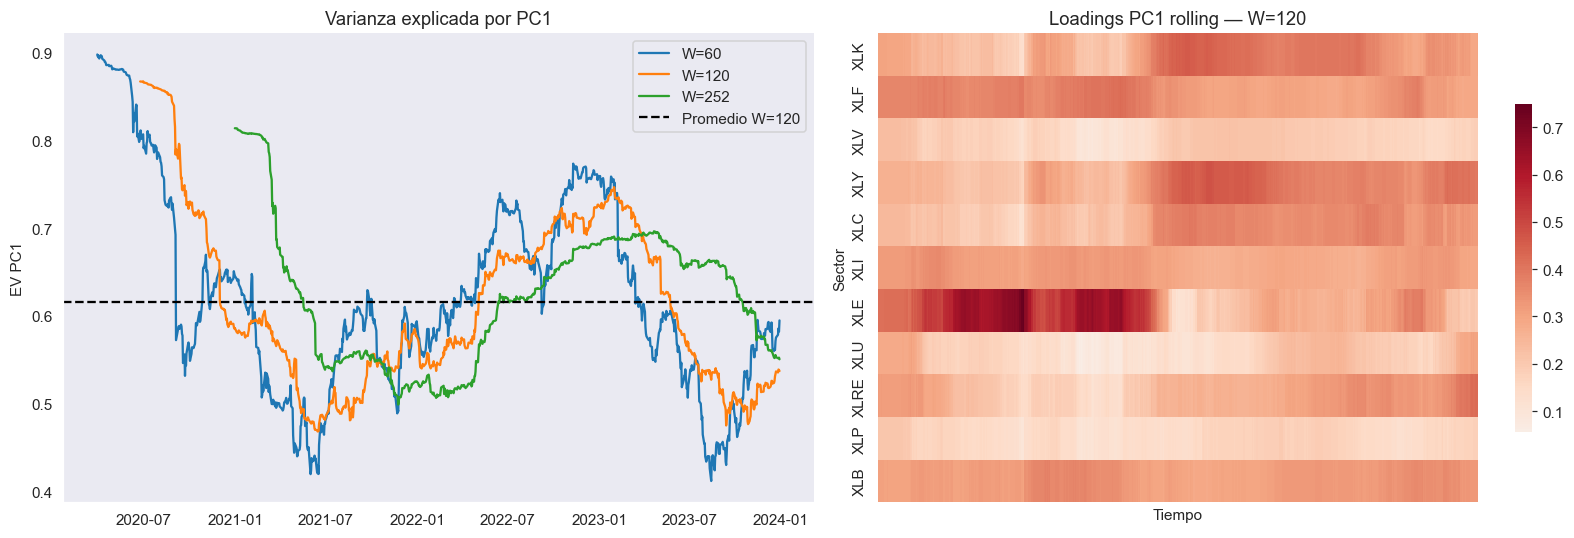

In [55]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

for W in windows:
    ev, load, d = results_rpca[W]
    ax1.plot(d, ev, label=f'W={W}')

ev120, load120, d120 = results_rpca[120]

ax1.axhline(ev120.mean(), color='black', linestyle='--', label='Promedio W=120')
ax1.set_title('Varianza explicada por PC1')
ax1.set_ylabel('EV PC1')
ax1.legend()

sns.heatmap(
    load120.T,
    ax=ax2,
    cmap='RdBu_r',
    center=0,
    yticklabels=sector_tickers,
    xticklabels=False,
    cbar_kws={'shrink': 0.7}
)

ax2.set_title('Loadings PC1 rolling — W=120')
ax2.set_xlabel('Tiempo')
ax2.set_ylabel('Sector')

plt.tight_layout()
plt.show()

### 4.2 — Varianza PC1 como Señal de Régimen *(13 pts)*

La varianza explicada por PC1 mide el **nivel de correlación sistémica** del mercado. Cuando supera un umbral $\theta$, el mercado está en un régimen de alta correlación (crisis). La estrategia es simple:

$$\text{exposición}_t = \begin{cases} 1 & \text{si } \text{ev}_{\text{PC1},t} \leq \theta \\ \alpha & \text{si } \text{ev}_{\text{PC1},t} > \theta \end{cases}$$

con $\alpha = 0.3$ (reduce la posición pero no sale completamente).

**Aplicación:** sobre el ETF SPY con $W=120$ y $\theta = \text{percentil}_{75}(\text{ev}_{\text{PC1}})$:

1. Calcular la señal `ev_PC1_t` usando `rolling_pca` sobre los 11 sectores
2. Construir la serie de exposición `exp_t` según la regla anterior (**lag 1 día para evitar leakage**)
3. Calcular retornos de la estrategia: $r_t^{\text{strat}} = \text{exp}_{t-1} \cdot r_t^{\text{SPY}}$
4. Comparar con buy-and-hold SPY en el período donde `ev_PC1` está disponible:
   - Retorno total, volatilidad anualizada, Sharpe ratio, Max Drawdown
5. Generar: (a) retorno acumulado comparado, (b) evolución de `ev_PC1` y exposición

In [14]:
# Descomenta cuando hayas completado 4.1

# ev_120, _, dates_120 = results_rpca[120]
# theta = np.percentile(ev_120, 75)
# print(f'Umbral theta (p75): {theta:.3f}')

# Señal de exposicion (lag 1 dia)
# alpha_red = 0.3
# exposure  = np.where(ev_120 > theta, alpha_red, 1.0)
# exp_lagged = np.concatenate([[1.0], exposure[:-1]])  # lag 1 para evitar leakage

# Retornos SPY en el mismo periodo
# spy_all = yf.download('SPY', start='2020-01-01', end='2024-01-01',
#                       progress=False, auto_adjust=True)['Close']
# r_spy_all = spy_all.pct_change().dropna()
# r_spy_strat_period = r_spy_all.reindex(pd.DatetimeIndex(dates_120)).dropna()
# print(f'Dias estrategia: {len(r_spy_strat_period)}')

# TODO: asegurar que exp_lagged tiene el mismo largo que r_spy_strat_period
# r_strat = exp_lagged[:len(r_spy_strat_period)] * r_spy_strat_period.values
# r_bh    = r_spy_strat_period.values

# TODO: calcula y tabula metricas
# def metrics_portfolio(r, freq=252):
#     cum = np.cumprod(1 + r)
#     mdd = (cum / np.maximum.accumulate(cum) - 1).min()
#     return {
#         'Retorno Total':   cum[-1] - 1,
#         'Vol Anual':       r.std() * np.sqrt(freq),
#         'Sharpe':          r.mean() / r.std() * np.sqrt(freq),
#         'Max Drawdown':    mdd
#     }

# df_metrics_strat = pd.DataFrame({
#     'Buy & Hold SPY': metrics_portfolio(r_bh),
#     'Estrategia PC1': metrics_portfolio(r_strat),
# })
# display(df_metrics_strat.T.round(3))

# TODO: 2 paneles: retorno acumulado + ev_PC1 con exposicion
pass

**Responde (mínimo 2 oraciones por pregunta):**

**a)** ¿En qué fechas específicas fue mayor la varianza explicada por PC1? ¿Coinciden con eventos de mercado conocidos (COVID-19, subidas de tasas Fed 2022)?

> *Completa aquí*

**b)** Compara el Sharpe ratio y el Max Drawdown de la estrategia basada en PC1 vs buy-and-hold. ¿La reducción de exposición en regímenes de alta correlación mejora el perfil riesgo-retorno?

> *Completa aquí*

**c)** ¿Qué sesgo introduce el lag de 1 día en la señal de exposición? ¿Sería correcto usar `exposure` directamente sin lag? Argumenta en términos de leakage.

> *Completa aquí*

**d)** Compara las curvas de `ev_PC1` para $W=60$, $120$ y $252$. ¿Cuál ventana reacciona más rápido a los cambios de régimen? ¿Cuál tiene menor ruido? ¿Cómo elegirías $W$ en producción?

> *Completa aquí*

---
## Parte 5 — Sparse PCA y Robust PCA *(Bonus — 15 pts)*

### Contexto

Las extensiones de PCA presentadas al final de la sesión abordan dos limitaciones del PCA estándar:

1. **Sparse PCA:** produce loadings con muchos ceros → factores interpretables como "portfolios de pocos activos"
2. **Robust PCA:** separa la componente de bajo rango (factores comunes) de los outliers/jumps (componente sparse)

### 5.1 — Sparse PCA: Interpretabilidad vs Varianza Explicada *(5 pts)*

Aplica Sparse PCA con distintos valores de $\alpha \in \{0.1, 0.5, 1.0, 2.0\}$ sobre los retornos de los 11 ETFs.

Para cada $\alpha$, calcula:
- **Sparsidad:** `(components == 0).mean()` — fracción de loadings exactamente cero
- **Varianza explicada** (aproximada): `sum(loadings^2) / sum(Sigma_diag)` para PC1

Genera un gráfico de **sparsidad vs $\alpha$** y un heatmap comparativo de los loadings de PCA estándar vs Sparse PCA ($\alpha=0.5$).

In [15]:
# TODO: Ajusta SparsePCA para alpha in [0.1, 0.5, 1.0, 2.0]
# alphas_spca = [0.1, 0.5, 1.0, 2.0]
# sparsity_list = []
# for alpha_s in alphas_spca:
#     spca_s = SparsePCA(n_components=3, alpha=alpha_s, random_state=42, max_iter=300)
#     spca_s.fit(ret_sec.values)
#     sparsity_list.append((spca_s.components_ == 0).mean())
#     print(f'alpha={alpha_s}: sparsidad={sparsity_list[-1]:.1%}')

# TODO: Genera 2 paneles
# Panel 1: sparsidad vs alpha
# Panel 2: heatmap comparativo PCA estandar vs SPCA (alpha=0.5)
#   Muestra los 3 primeros componentes de cada metodo
pass

**Responde:**

**a)** En el Sparse PCA con $\alpha=0.5$, ¿qué sectores tienen loadings cero en PC1? ¿Tiene sentido financiero que esos sectores sean excluidos del primer factor?

> *Completa aquí*

### 5.2 — Robust PCA: Separación de Factores y Jumps *(10 pts)*

Los retornos de activos contienen tanto factores comunes (movimientos sistemáticos de mercado) como saltos idiosincráticos (earnings surprise, M&A, eventos regulatorios). Robust PCA los separa:

$$X = L + S, \quad \min_{L,S} \|L\|_* + \lambda \|S\|_1$$

donde $L$ es la componente de bajo rango (factores) y $S$ es sparse (jumps).

Usa la implementación del algoritmo IALM (Inexact Augmented Lagrangian Method) de la clase:

**Requisitos:**
1. Copiar la función `robust_pca` de la clase e inyectar 20 jumps artificiales de magnitud $5\sigma$ en `ret_sec`
2. Aplicar Robust PCA sobre los datos con jumps
3. Verificar la recuperación: ¿cuántos de los 20 jumps inyectados detecta el componente $S$?
4. Comparar el PCA estándar sobre $X$ vs PCA sobre $L$ (la componente limpia): ¿cómo cambia la varianza explicada por PC1?
5. Generar el panel de 3 heatmaps: $X$ (con jumps) | $L$ (bajo rango) | $S$ (sparse)

In [16]:
def robust_pca_ialm(M, lam=None, max_iter=500, tol=1e-7, mu=None):
    """
    Robust PCA via IALM (Candes et al. 2011).
    Descompone M = L + S donde L es low-rank y S es sparse.

    [Copiado de clase_05 — no modifiques esta funcion]
    """
    m, n = M.shape
    lam  = lam  or 1.0 / np.sqrt(max(m, n))
    mu   = mu   or m * n / (4 * np.abs(M).sum())
    mu_bar = mu * 1e7
    rho  = 1.5
    L, S, Y = np.zeros_like(M), np.zeros_like(M), np.zeros_like(M)
    norm_M   = np.linalg.norm(M, 'fro')

    def shrink(X, tau):
        return np.sign(X) * np.maximum(np.abs(X) - tau, 0)

    def svd_threshold(X, tau):
        U, s, Vt = np.linalg.svd(X, full_matrices=False)
        return U @ np.diag(np.maximum(s - tau, 0)) @ Vt

    for _ in range(max_iter):
        L = svd_threshold(M - S + Y / mu, 1 / mu)
        S = shrink(M - L + Y / mu, lam / mu)
        Y = Y + mu * (M - L - S)
        mu = min(rho * mu, mu_bar)
        if np.linalg.norm(M - L - S, 'fro') / norm_M < tol:
            break
    return L, S


# TODO 1: Inyecta 20 jumps artificiales de magnitud 5*sigma
# ret_noisy = ret_sec.values.copy()
# np.random.seed(42)
# jump_rows = np.random.choice(len(ret_noisy), 20, replace=False)
# jump_cols = np.random.choice(ret_noisy.shape[1], 20, replace=False)
# sigma_ret = ret_noisy.std(axis=0)
# for r, c in zip(jump_rows, jump_cols):
#     ret_noisy[r, c] += np.random.choice([-1, 1]) * 5 * sigma_ret[c]

# TODO 2: Aplica Robust PCA (puede tardar ~30 seg)
# L_rec, S_rec = robust_pca_ialm(ret_noisy, max_iter=300)

# TODO 3: Verifica recuperacion de jumps
# mask_S_detected = np.abs(S_rec) > 2 * sigma_ret
# detected = sum(mask_S_detected[r, c] for r, c in zip(jump_rows, jump_cols))
# print(f'Jumps inyectados: 20 | Detectados en S: {detected}')

# TODO 4: Compara varianza PC1 en X vs L
# pca_X = PCA(n_components=3).fit(ret_noisy)
# pca_L = PCA(n_components=3).fit(L_rec)
# print(f'Var PC1 en X (con jumps): {pca_X.explained_variance_ratio_[0]:.3f}')
# print(f'Var PC1 en L (low-rank):  {pca_L.explained_variance_ratio_[0]:.3f}')

# TODO 5: Panel de 3 heatmaps
# fig, axes = plt.subplots(1, 3, figsize=(16, 4))
# Para cada matriz: ax.imshow(matriz.T, aspect='auto', cmap='RdBu_r', vmin=-vm, vmax=vm)
pass

**Responde:**

**a)** ¿Cuántos de los 20 jumps inyectados detectó el componente $S$? ¿En qué tipos de jumps falló la detección (magnitud baja, overlap con movimientos normales)?

> *Completa aquí*

**b)** ¿Cómo cambia la varianza explicada por PC1 entre PCA sobre $X$ (con jumps) vs PCA sobre $L$ (componente limpia)? ¿En qué dirección cambia y por qué?

> *Completa aquí*

**c)** En un pipeline de gestión de riesgo en producción, ¿antes o después de Robust PCA aplicarías el Rolling PCA de la Parte 4? Argumenta el orden correcto.

> *Completa aquí*

---
## Tabla de Puntajes

| Parte | Descripción | Pts |
|---|---|---|
| 1.1 | `pca_eigen` + `pca_svd` (error < 1e-10 vs sklearn) | 12 |
| 1.2 | `select_k_criteria` (var80 + Kaiser + Bai-Ng) + panel 4 gráficos × 2 datasets + 3 preguntas | 13 |
| 2.1 | PCA sobre $\Delta y$ + loadings vs NS teórico + correlaciones + gráfico | 10 |
| 2.2 | `dv01_factorial` + butterfly trade (sistema lineal) + P&L simulado + 3 preguntas | 15 |
| 3.1 | PCA $k=4$ + heatmap loadings + barplot PC1 + correlación SPY + 2 preguntas | 8 |
| 3.2 | `pca_shrinkage_cov` (verificación eigenvalores) + gráfico condicionamiento + heatmaps | 10 |
| 3.3 | `gmv_portfolio` + split temporal + métricas OOT + gráficos + 2 preguntas | 7 |
| 4.1 | `rolling_pca` con alineación de signos + 3 ventanas + heatmap loadings | 12 |
| 4.2 | Estrategia régimen PC1 + lag correcto + métricas + gráficos + 4 preguntas | 13 |
| **Total obligatorio** | | **100** |
| Bonus 5.1 | Sparse PCA × 4 alphas + sparsidad + heatmap comparativo + pregunta | 5 |
| Bonus 5.2 | Robust PCA + recuperación de jumps + comparación varianza + 3 preguntas | 10 |